Matriz inicial de feromônio:
[[0. 1. 1. 0. 0. 0.]
 [1. 0. 1. 1. 0. 0.]
 [1. 1. 0. 1. 1. 0.]
 [0. 1. 1. 0. 1. 1.]
 [0. 0. 1. 1. 0. 1.]
 [0. 0. 0. 1. 1. 0.]]

Vizinhos do nó 0: [1, 2]
Vizinhos do nó 2: [0, 1, 3, 4]

Rotas encontradas:
Formiga 1: [0, 1, 2, 3, 4, 5]
Formiga 2: [0, 1, 2, 3, 4, 5]
Formiga 3: [0, 1, 2, 3, 4, 5]
Formiga 4: [0, 1, 2, 3, 4, 5]
Formiga 5: [0, 2, 1, 3, 4, 5]

Teste de cálculo:
Rota: [0, 1, 2, 3, 4, 5]
Custo: 8.0

RESULTADO FINAL
Melhor rota encontrada: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


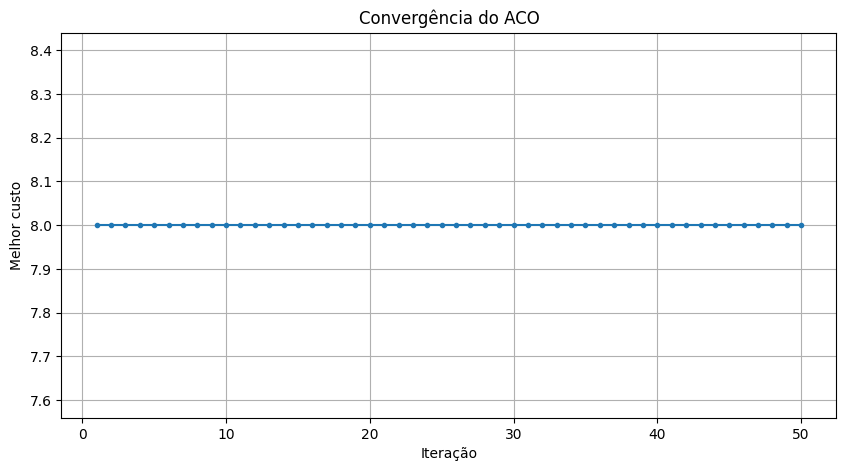

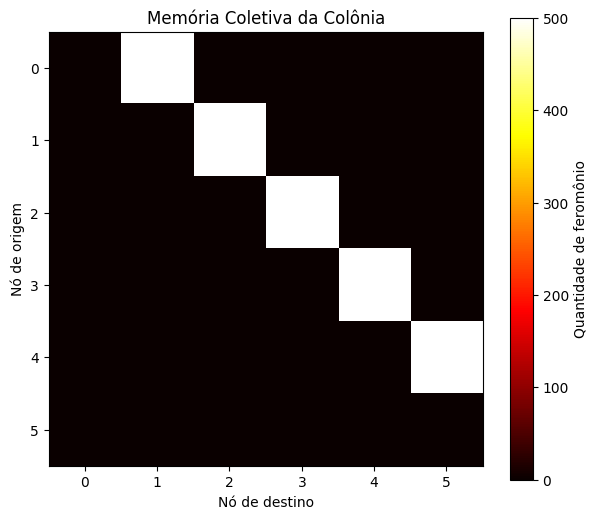


Concentração final de feromônio:
Nó 0 -> Nó 1: 500.00
Nó 0 -> Nó 2: 0.00
Nó 1 -> Nó 0: 0.00
Nó 1 -> Nó 2: 500.00
Nó 1 -> Nó 3: 0.00
Nó 2 -> Nó 0: 0.00
Nó 2 -> Nó 1: 0.00
Nó 2 -> Nó 3: 500.00
Nó 2 -> Nó 4: 0.00
Nó 3 -> Nó 1: 0.00
Nó 3 -> Nó 2: 0.00
Nó 3 -> Nó 4: 500.00
Nó 3 -> Nó 5: 0.00
Nó 4 -> Nó 2: 0.00
Nó 4 -> Nó 3: 0.00
Nó 4 -> Nó 5: 500.00
Nó 5 -> Nó 3: 0.00
Nó 5 -> Nó 4: 0.00


In [4]:
# ============================================================
# LABORATÓRIO — ACO: OTIMIZAÇÃO POR COLÔNIA DE FORMIGAS
# ============================================================


# ------------------------------------------------------------
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ------------------------------------------------------------

# Importa a biblioteca NumPy.
# Ela será utilizada para trabalhar com a matriz de custos.
import numpy as np

# Importa o módulo random.
# Ele será utilizado para fazer as escolhas probabilísticas
# das formigas.
import random

# Importa o módulo pyplot da biblioteca Matplotlib.
# Ele será utilizado para criar os gráficos.
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# DEFININDO UMA SEMENTE ALEATÓRIA
# ------------------------------------------------------------

# O ACO utiliza escolhas aleatórias.
# Normalmente, cada execução poderia produzir um resultado
# ligeiramente diferente.

# Ao utilizar a semente 42, conseguimos repetir a mesma
# sequência de números aleatórios.
random.seed(42)

# Faz a mesma coisa para o NumPy.
np.random.seed(42)


# ============================================================
# 2. REPRESENTAÇÃO DA REDE
# ============================================================

# Criamos uma matriz chamada CUSTOS.
#
# Cada linha representa o nó de origem.
# Cada coluna representa o nó de destino.
#
# Por exemplo:
#
# CUSTOS[0][1] = 2
#
# significa que o custo para ir do nó 0 para o nó 1 é 2.

CUSTOS = np.array([

    # Nó 0:
    # Pode ir para o nó 1 com custo 2.
    # Pode ir para o nó 2 com custo 4.
    [0, 2, 4, np.inf, np.inf, np.inf],

    # Nó 1:
    # Pode ir para 0 com custo 2.
    # Pode ir para 2 com custo 1.
    # Pode ir para 3 com custo 5.
    [2, 0, 1, 5, np.inf, np.inf],

    # Nó 2:
    # Pode ir para 0 com custo 4.
    # Pode ir para 1 com custo 1.
    # Pode ir para 3 com custo 2.
    # Pode ir para 4 com custo 3.
    [4, 1, 0, 2, 3, np.inf],

    # Nó 3:
    # Pode ir para 1 com custo 5.
    # Pode ir para 2 com custo 2.
    # Pode ir para 4 com custo 1.
    # Pode ir para 5 com custo 4.
    [np.inf, 5, 2, 0, 1, 4],

    # Nó 4:
    # Pode ir para 2 com custo 3.
    # Pode ir para 3 com custo 1.
    # Pode ir para 5 com custo 2.
    [np.inf, np.inf, 3, 1, 0, 2],

    # Nó 5:
    # Pode voltar para 3 com custo 4.
    # Pode voltar para 4 com custo 2.
    [np.inf, np.inf, np.inf, 4, 2, 0]

], dtype=float)


# Define o nó onde todas as formigas começam.
# O número 0 representa o primeiro nó.
ORIGEM = 0

# Define o nó que as formigas precisam alcançar.
# O número 5 representa o destino.
DESTINO = 5


# ============================================================
# 3. PARÂMETROS DO ACO
# ============================================================

# Quantidade de formigas utilizadas em cada iteração.
#
# Neste exemplo, 20 formigas tentarão encontrar uma rota.
NUM_FORMIGAS = 20


# Número de vezes que a colônia irá repetir o processo.
#
# Quanto maior o número de iterações, mais oportunidades
# o algoritmo terá para melhorar sua solução.
NUM_ITERACOES = 50


# ALPHA determina a importância do feromônio.
#
# Se ALPHA for maior, as formigas darão mais importância
# aos caminhos que já possuem bastante feromônio.
ALPHA = 1.0


# BETA determina a importância do custo.
#
# Quanto maior o BETA, maior será a preferência por
# caminhos de menor custo.
BETA = 2.0


# Define quanto do feromônio será evaporado.
#
# 0.5 significa que 50% do feromônio será perdido
# a cada iteração.
TAXA_EVAPORACAO = 0.5


# Q determina a quantidade de feromônio depositada.
#
# Quanto menor o custo da rota, maior será o depósito.
Q = 100


# ============================================================
# 4. CRIAÇÃO DA MATRIZ DE FEROMÔNIO
# ============================================================

# Criamos uma matriz de feromônio com o mesmo tamanho
# da matriz de custos.
#
# np.ones_like cria uma matriz preenchida com 1.
#
# dtype=float garante que poderemos trabalhar com
# números decimais.
feromonio = np.ones_like(CUSTOS, dtype=float)


# Onde CUSTOS possui np.inf significa que não existe
# conexão entre os nós.
#
# Portanto, também colocamos 0 de feromônio nesses locais.
feromonio[CUSTOS == np.inf] = 0


# Colocamos 0 na diagonal principal.
#
# A diagonal representa ir de um nó para ele mesmo:
#
# 0 -> 0
# 1 -> 1
# 2 -> 2
# etc.
#
# Isso não interessa para o nosso problema.
np.fill_diagonal(feromonio, 0)


# Mostra no Colab a matriz inicial de feromônio.
print("Matriz inicial de feromônio:")

# Exibe a matriz na tela.
print(feromonio)


# ============================================================
# 5. ENCONTRANDO OS VIZINHOS DE UM NÓ
# ============================================================

# Criamos uma função chamada obter_vizinhos.
#
# Ela recebe como parâmetro o número de um nó.
#
# Exemplo:
#
# obter_vizinhos(0)
#
# retornará os nós diretamente conectados ao nó 0.
def obter_vizinhos(no):

    # Criamos uma lista vazia.
    #
    # Nessa lista vamos colocar os nós que podem ser
    # alcançados a partir do nó atual.
    vizinhos = []


    # O range percorre todos os nós existentes.
    #
    # Como temos 6 nós:
    #
    # range(6) = 0, 1, 2, 3, 4, 5
    for proximo in range(len(CUSTOS)):

        # Verificamos duas condições:
        #
        # 1. proximo != no
        #    Não queremos que a formiga vá para o
        #    mesmo nó onde já está.
        #
        # 2. CUSTOS[no][proximo] != np.inf
        #    Significa que existe uma conexão direta.
        if (
            proximo != no
            and CUSTOS[no][proximo] != np.inf
        ):

            # Se as duas condições forem verdadeiras,
            # adicionamos o nó à lista de vizinhos.
            vizinhos.append(proximo)


    # Retornamos a lista de vizinhos.
    return vizinhos


# ============================================================
# TESTANDO A FUNÇÃO
# ============================================================

# Verifica quais são os vizinhos do nó 0.
print("\nVizinhos do nó 0:", obter_vizinhos(0))


# Verifica quais são os vizinhos do nó 2.
print("Vizinhos do nó 2:", obter_vizinhos(2))


# ============================================================
# 6. ESCOLHENDO O PRÓXIMO NÓ
# ============================================================

# Esta é uma das partes mais importantes do ACO.
#
# A função decide para qual nó a formiga irá em seguida.
#
# Ela considera:
#
# - quantidade de feromônio;
# - custo da conexão;
# - nós que já foram visitados.
def escolher_proximo(no_atual, visitados):


    # Primeiro descobrimos quais nós estão conectados
    # diretamente ao nó atual.
    vizinhos = obter_vizinhos(no_atual)


    # Agora retiramos os nós que a formiga já visitou.
    #
    # Isso evita que a formiga fique andando em círculos.
    candidatos = [
        no for no in vizinhos
        if no not in visitados
    ]


    # Se não houver nenhum candidato disponível,
    # significa que a formiga ficou sem saída.
    if not candidatos:

        # Retornamos None para indicar que não foi possível
        # continuar a construção da rota.
        return None


    # Criamos uma lista vazia.
    #
    # Nela vamos armazenar a "atratividade" de cada candidato.
    atratividades = []


    # Percorremos todos os possíveis próximos nós.
    for proximo in candidatos:

        # Obtém a quantidade de feromônio existente
        # na conexão entre o nó atual e o próximo.
        fer = feromonio[no_atual][proximo]


        # Obtém o custo da conexão.
        custo = CUSTOS[no_atual][proximo]


        # Calculamos a atratividade.
        #
        # Fórmula utilizada pelo ACO:
        #
        # atratividade =
        # feromônio^ALPHA *
        # (1/custo)^BETA
        #
        # Portanto:
        #
        # mais feromônio = mais atratividade
        #
        # menor custo = mais atratividade.
        atratividade = (
            (fer ** ALPHA) *
            ((1 / custo) ** BETA)
        )


        # Adicionamos o valor calculado à lista.
        atratividades.append(atratividade)


    # Calculamos a soma de todas as atratividades.
    #
    # Essa soma será utilizada para transformar
    # as atratividades em probabilidades.
    soma = sum(atratividades)


    # Caso a soma seja zero, não podemos dividir por zero.
    #
    # Nesse caso, damos a mesma probabilidade
    # para todos os candidatos.
    if soma == 0:

        probabilidades = [
            1 / len(candidatos)
            for _ in candidatos
        ]

    else:

        # Transformamos cada atratividade em uma probabilidade.
        #
        # Exemplo:
        #
        # atratividades = [2, 3, 5]
        #
        # soma = 10
        #
        # probabilidades = [0.2, 0.3, 0.5]
        probabilidades = [
            valor / soma
            for valor in atratividades
        ]


    # Fazemos uma escolha aleatória.
    #
    # random.choices permite escolher um elemento
    # considerando pesos diferentes.
    #
    # Quanto maior a probabilidade, maior a chance
    # de aquele nó ser escolhido.
    proximo = random.choices(
        candidatos,
        weights=probabilidades,
        k=1
    )[0]


    # Retornamos o nó escolhido.
    return proximo


# ============================================================
# 7. CONSTRUINDO UMA ROTA
# ============================================================

# Esta função representa uma formiga construindo
# sua própria rota.
def construir_rota():

    # A rota começa no nó de origem.
    #
    # Como ORIGEM = 0:
    #
    # rota = [0]
    rota = [ORIGEM]


    # A formiga começa atualmente no nó de origem.
    atual = ORIGEM


    # Enquanto a formiga ainda não chegou ao destino,
    # continuamos escolhendo novos nós.
    while atual != DESTINO:


        # Escolhemos o próximo nó.
        #
        # Passamos:
        # - onde a formiga está;
        # - os nós que ela já visitou.
        proximo = escolher_proximo(
            atual,
            rota
        )


        # Se não houver próximo nó,
        # a formiga ficou sem caminho.
        if proximo is None:

            # Retornamos None para informar que
            # a rota não foi concluída.
            return None


        # Adicionamos o novo nó à rota.
        rota.append(proximo)


        # Atualizamos a posição atual da formiga.
        atual = proximo


    # Quando chegamos aqui,
    # significa que a formiga chegou ao destino.
    #
    # Então retornamos a rota completa.
    return rota


# ============================================================
# TESTANDO ALGUMAS FORMIGAS
# ============================================================

# Mostra um título na tela.
print("\nRotas encontradas:")


# Vamos criar 5 formigas apenas para testar
# a construção de rotas.
for i in range(5):

    # Cada formiga constrói sua própria rota.
    rota = construir_rota()


    # Mostramos o número da formiga e a rota encontrada.
    print(f"Formiga {i + 1}: {rota}")


# ============================================================
# 8. CALCULANDO O CUSTO DA ROTA
# ============================================================

# Esta função recebe uma rota e calcula seu custo total.
#
# Exemplo:
#
# rota = [0, 1, 2, 4, 5]
#
# O cálculo será:
#
# 0 -> 1 = 2
# 1 -> 2 = 1
# 2 -> 4 = 3
# 4 -> 5 = 2
#
# Total = 8
def calcular_custo(rota):

    # Começamos o custo total em zero.
    total = 0


    # Percorremos cada posição da rota,
    # exceto a última.
    #
    # len(rota) - 1 evita tentar acessar uma posição
    # que não existe.
    for i in range(len(rota) - 1):


        # Pegamos o nó atual.
        origem = rota[i]


        # Pegamos o próximo nó.
        destino = rota[i + 1]


        # Adicionamos o custo da conexão ao total.
        total += CUSTOS[origem][destino]


    # Retornamos o custo total.
    return total


# ============================================================
# TESTANDO O CÁLCULO DO CUSTO
# ============================================================

# Construímos uma rota.
rota = construir_rota()


# Verificamos se uma rota foi encontrada.
if rota is not None:

    # Calculamos seu custo.
    custo = calcular_custo(rota)


    # Mostramos a rota.
    print("\nTeste de cálculo:")
    print("Rota:", rota)


    # Mostramos o custo.
    print("Custo:", custo)


# ============================================================
# 9. DEPÓSITO DE FEROMÔNIO
# ============================================================

# Esta função adiciona feromônio às conexões
# utilizadas por uma formiga.
def depositar_feromonio(rota, custo):


    # Evitamos divisão por zero.
    if custo <= 0:
        return


    # Calculamos quanto de feromônio será depositado.
    #
    # Fórmula:
    #
    # depósito = Q / custo
    #
    # Portanto:
    #
    # custo baixo -> depósito alto
    #
    # custo alto -> depósito baixo.
    deposito = Q / custo


    # Percorremos todos os enlaces da rota.
    for i in range(len(rota) - 1):

        # Pegamos o nó de origem.
        origem = rota[i]


        # Pegamos o nó de destino.
        destino = rota[i + 1]


        # Adicionamos feromônio à conexão.
        feromonio[origem][destino] += deposito


# ============================================================
# 10. EVAPORAÇÃO DO FEROMÔNIO
# ============================================================

# Esta função representa a evaporação do feromônio.
def evaporar_feromonio():

    # Estamos modificando a variável feromonio
    # que foi criada fora da função.
    #
    # Por isso precisamos declarar que ela é global.
    global feromonio


    # Aplicamos a evaporação.
    #
    # TAXA_EVAPORACAO = 0.5
    #
    # Então:
    #
    # feromonio *= (1 - 0.5)
    #
    # feromonio *= 0.5
    #
    # Ou seja, fica apenas 50% do feromônio.
    feromonio *= (1 - TAXA_EVAPORACAO)


    # Garantimos que as conexões inexistentes
    # continuem com feromônio igual a zero.
    feromonio[CUSTOS == np.inf] = 0


    # Também mantemos zero na diagonal.
    np.fill_diagonal(feromonio, 0)


# ============================================================
# 11. EXECUÇÃO PRINCIPAL DO ACO
# ============================================================

# Ainda não temos uma melhor rota.
#
# Por isso começamos com None.
melhor_rota = None


# Começamos o melhor custo com infinito.
#
# Qualquer rota válida terá um custo menor que infinito.
melhor_custo = float("inf")


# Criamos uma lista para guardar a evolução
# do melhor custo durante as iterações.
historico = []


# Começamos o processo de otimização.
#
# O loop será executado 50 vezes.
for iteracao in range(NUM_ITERACOES):


    # Criamos uma lista vazia para guardar
    # as rotas construídas pelas formigas.
    rotas = []


    # Criamos as formigas.
    #
    # Se NUM_FORMIGAS = 20,
    # teremos 20 formigas por iteração.
    for _ in range(NUM_FORMIGAS):


        # Cada formiga constrói uma rota.
        rota = construir_rota()


        # Verificamos se a rota foi concluída.
        if rota is not None:


            # Calculamos o custo da rota.
            custo = calcular_custo(rota)


            # Guardamos a rota e seu custo.
            rotas.append((rota, custo))


            # Verificamos se essa rota é melhor
            # que a melhor rota encontrada anteriormente.
            if custo < melhor_custo:


                # Atualizamos o melhor custo.
                melhor_custo = custo


                # Copiamos a rota para guardar
                # a melhor solução encontrada.
                melhor_rota = rota.copy()


    # ========================================================
    # EVAPORAÇÃO
    # ========================================================

    # Antes de adicionar novo feromônio,
    # uma parte do feromônio antigo desaparece.
    evaporar_feromonio()


    # ========================================================
    # DEPÓSITO
    # ========================================================

    # Agora percorremos todas as rotas encontradas
    # pelas formigas nesta iteração.
    for rota, custo in rotas:


        # Cada formiga deposita feromônio
        # na sua própria rota.
        depositar_feromonio(
            rota,
            custo
        )


    # Guardamos o melhor custo encontrado até agora.
    #
    # Isso será utilizado posteriormente
    # para construir o gráfico de convergência.
    historico.append(melhor_custo)


# ============================================================
# 12. RESULTADO FINAL
# ============================================================

# Imprime uma linha de separação.
print("\n" + "=" * 50)


# Imprime o título.
print("RESULTADO FINAL")


# Imprime outra linha de separação.
print("=" * 50)


# Mostra a melhor rota encontrada pelo algoritmo.
print("Melhor rota encontrada:", melhor_rota)


# Mostra o custo dessa rota.
print("Melhor custo:", melhor_custo)


# ============================================================
# 13. GRÁFICO DE CONVERGÊNCIA
# ============================================================

# Define o tamanho do gráfico.
plt.figure(figsize=(10, 5))


# Desenha a evolução do melhor custo.
#
# range(1, NUM_ITERACOES + 1)
# cria os números:
#
# 1, 2, 3, ..., 50
#
# historico contém o melhor custo encontrado
# em cada uma dessas iterações.
plt.plot(
    range(1, NUM_ITERACOES + 1),
    historico,
    marker="o",
    markersize=3
)


# Nome do eixo X.
plt.xlabel("Iteração")


# Nome do eixo Y.
plt.ylabel("Melhor custo")


# Título do gráfico.
plt.title("Convergência do ACO")


# Ativa a grade do gráfico.
plt.grid(True)


# Mostra o gráfico.
plt.show()


# ============================================================
# 14. MATRIZ FINAL DE FEROMÔNIO
# ============================================================

# Cria uma nova figura.
plt.figure(figsize=(7, 6))


# Mostra a matriz de feromônio como uma imagem.
#
# Quanto maior o valor do feromônio,
# mais intensa será a cor.
plt.imshow(
    feromonio,
    cmap="hot"
)


# Cria uma barra lateral indicando
# a quantidade de feromônio.
plt.colorbar(
    label="Quantidade de feromônio"
)


# Nome do eixo horizontal.
plt.xlabel("Nó de destino")


# Nome do eixo vertical.
plt.ylabel("Nó de origem")


# Título do gráfico.
plt.title("Memória Coletiva da Colônia")


# Mostra os números dos nós no eixo X.
plt.xticks(range(len(CUSTOS)))


# Mostra os números dos nós no eixo Y.
plt.yticks(range(len(CUSTOS)))


# Exibe o gráfico.
plt.show()


# ============================================================
# 15. MOSTRANDO AS CONEXÕES COM MAIS FEROMÔNIO
# ============================================================

# Imprime um título.
print("\nConcentração final de feromônio:")


# Percorre todas as linhas da matriz.
for i in range(len(CUSTOS)):


    # Percorre todas as colunas da matriz.
    for j in range(len(CUSTOS)):


        # Verificamos três condições:
        #
        # 1. i != j
        #    Não queremos mostrar a diagonal.
        #
        # 2. CUSTOS[i][j] != np.inf
        #    A conexão precisa existir.
        #
        # 3. feromonio[i][j] > 0
        #    Precisamos ter algum feromônio.
        if (
            i != j
            and CUSTOS[i][j] != np.inf
            and feromonio[i][j] > 0
        ):


            # Mostra a conexão e a quantidade
            # final de feromônio.
            #
            # :.2f significa mostrar apenas
            # duas casas decimais.
            print(
                f"Nó {i} -> Nó {j}: "
                f"{feromonio[i][j]:.2f}"
            )
